# Notebook 1 – Kreditkartenbetrug erkennen mit XGBoost
**Maschinelles Lernen mit Python · Kapitel 12: Anomalieerkennung**  

---

## Lernziele dieses Notebooks

Nach Bearbeitung dieses Notebooks können Sie:
- den Kreditkartendatensatz und das Problem des **Klassenungleichgewichts** beschreiben
- erklären, warum **Accuracy** bei 0,173 % Betrugsfällen eine irreführende Metrik ist
- **Precision, Recall und F1-Score** aus einer Konfusionsmatrix berechnen und interpretieren
- einschätzen, welcher Fehlertyp (False Negative vs. False Positive) in der Betrugserkennung teurer ist
- XGBoost als robusten Baseline-Klassifizierer auf unbalancierten Daten anwenden

---

## Kontext und Problemstellung

Wir arbeiten mit dem **Kreditkartenbetrugs-Datensatz** der Université Libre de Bruxelles.  
Er enthält europäische Kreditkartentransaktionen aus September 2013:

| Merkmal | Beschreibung |
|---|---|
| **V1–V28** | PCA-transformierte und anonymisierte Features (Datenschutz) |
| **Time** | Sekunden seit der ersten Transaktion im Datensatz |
| **Amount** | Transaktionsbetrag in Euro |
| **Class** | Zielspalte: 0 = normal, 1 = Betrug |

> **Verbindung zu den Folien:** Abschnitt Anomalieerkennung · Merksatz: *Bei 0,173 % Betrugsfällen würde ein Modell, das immer 'kein Betrug' sagt, 99,83 % Accuracy erreichen – und trotzdem keinen einzigen Betrugsfall erkennen.*

---
## Schritt 1: Bibliotheken importieren

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score, accuracy_score)
from xgboost import XGBClassifier

---
## Schritt 2: Daten laden und erkunden

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

base_notebook_dir = "/content/drive/MyDrive/Colab Notebooks/DHBW Sommersemester 2026/Data"
path = os.path.join(base_notebook_dir, "creditcard.csv")

data = pd.read_csv(path, delimiter=',')
print(f"Datensatz geladen: {data.shape[0]:,} Zeilen, {data.shape[1]} Spalten")
data.head(3)

Mounted at /content/drive
Datensatz geladen: 284,807 Zeilen, 31 Spalten


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


Klassenverteilung:
  Normale Transaktionen (0): 284,315
  Betrugsfaelle      (1):     492
  Betrugsanteil:           0.173%

Denkaufgabe: Ein Modell, das IMMER 'kein Betrug' sagt, erreicht wie viel Accuracy?
  Antwort: 99.827% - und erkennt dennoch keinen Betrugsfall!


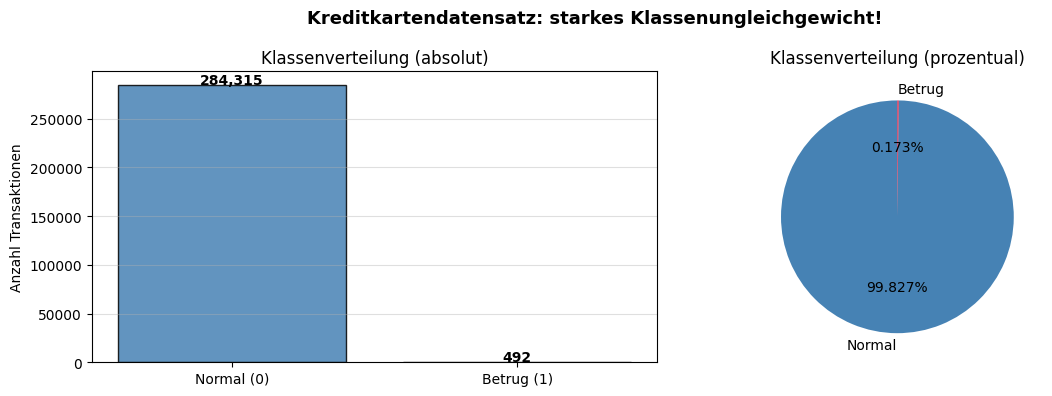

In [ ]:
# Klassenverteilung analysieren
verteilung = data['Class'].value_counts()
betrug_anteil = verteilung[1] / len(data) * 100

print("Klassenverteilung:")
print(f"  Normale Transaktionen (0): {verteilung[0]:>7,}")
print(f"  Betrugsfaelle      (1): {verteilung[1]:>7,}")
print(f"  Betrugsanteil:           {betrug_anteil:.3f}%")
print()
print("Denkaufgabe: Ein Modell, das IMMER 'kein Betrug' sagt, erreicht wie viel Accuracy?")
trivial_accuracy = verteilung[0] / len(data) * 100
print(f"  Antwort: {trivial_accuracy:.3f}% - und erkennt dennoch keinen Betrugsfall!")

# Visualisierung
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Normal (0)', 'Betrug (1)'], verteilung.values,
            color=['steelblue', 'crimson'], edgecolor='black', alpha=0.85)
axes[0].set_title('Klassenverteilung (absolut)', fontsize=12)
axes[0].set_ylabel('Anzahl Transaktionen')
for i, v in enumerate(verteilung.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')
axes[0].grid(True, axis='y', alpha=0.4)

axes[1].pie([verteilung[0], verteilung[1]],
            labels=['Normal', 'Betrug'],
            colors=['steelblue', 'crimson'],
            autopct='%1.3f%%',
            startangle=90)
axes[1].set_title('Klassenverteilung (prozentual)', fontsize=12)

plt.suptitle('Kreditkartendatensatz: starkes Klassenungleichgewicht!', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Schritt 3: Daten aufteilen

**Wichtig:** Wir verwenden `stratify=y`, damit das Trainings- und Test-Set dasselbe Verhältnis von Normal- zu Betrugsfällen haben.

In [ ]:
y = data['Class']
X = data.drop(['Class'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # gleiche Klassenverteilung in Train und Test!
)

print(f"Trainingsdaten: {X_train.shape[0]:,} Transaktionen")
print(f"Testdaten:      {X_test.shape[0]:,} Transaktionen")
print(f"Betrug im Test: {y_test.sum()} Faelle ({y_test.sum()/len(y_test)*100:.3f}%)")

Trainingsdaten: 227,845 Transaktionen
Testdaten:      56,962 Transaktionen
Betrug im Test: 98 Faelle (0.172%)


---
## Schritt 4: XGBoost trainieren

XGBoost ist besonders geeignet für tabellarische Daten. Wir trainieren direkt auf den **unbalancierten Rohdaten** – das ist der Baseline-Ansatz.

In [ ]:
# XGBoost initialisieren und trainieren
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # unterdrueckt Warnungen
    verbosity=0
)
xgb.fit(X_train, y_train)
print("Training abgeschlossen.")

Training abgeschlossen.


---
## Schritt 5: Vorhersage und Auswertung

In [ ]:
y_predicted = xgb.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_predicted)
print(f"Accuracy: {acc*100:.4f}%")
print()
print("Aber: Accuracy ist hier KEIN aussagekraeftiges Mass!")
print("Betrachten wir stattdessen die Konfusionsmatrix...")

Accuracy: 99.9438%

Aber: Accuracy ist hier KEIN aussagekraeftiges Mass!
Betrachten wir stattdessen die Konfusionsmatrix...


---
## Schritt 6: Konfusionsmatrix und Metriken

**Konfusionsmatrix – die vier Felder:**

| | Vorhergesagt: Normal | Vorhergesagt: Betrug |
|---|---|---|
| **Wahr: Normal** | True Negative (TN) ✅ | False Positive (FP) ⚠️ |
| **Wahr: Betrug** | False Negative (FN) ❌ | True Positive (TP) ✅ |

- **FN (False Negative):** Echten Betrug übersehen → finanzieller Schaden  
- **FP (False Positive):** Gute Transaktion blockiert → Kundenzufriedenheit sinkt

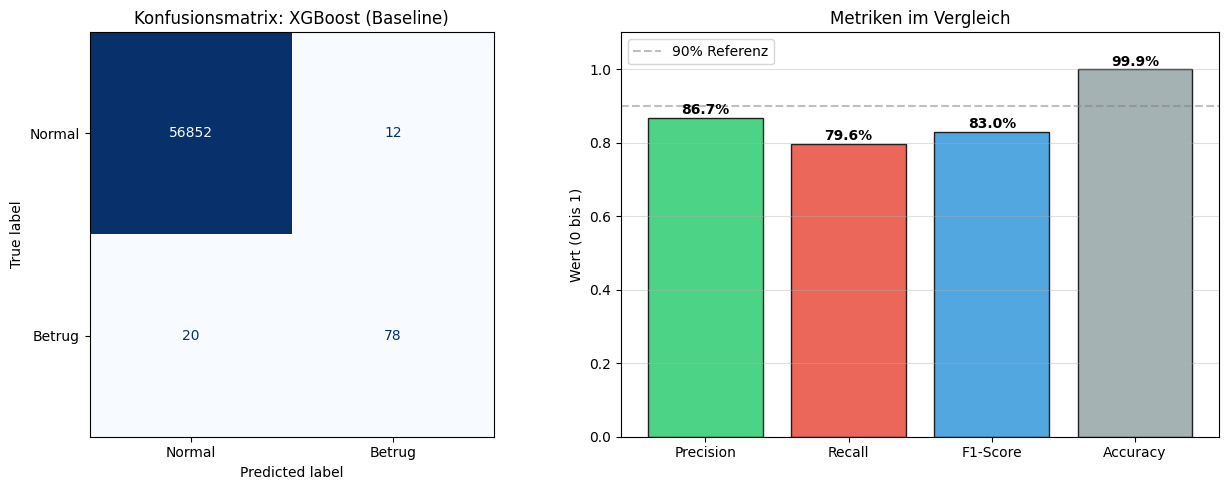

Konfusionsmatrix Detail:
  True Negative  (TN): 56,852  korrekt erkannte normale Transaktionen
  True Positive  (TP):     78    korrekt erkannte Betrugsfaelle
  False Negative (FN):     20    Betrugsfaelle NICHT erkannt (kritisch!)
  False Positive (FP):     12    faelschlich als Betrug markiert

Precision: 86.67%  (von 90 als Betrug markierten: 78 wirklich Betrug)
Recall:    79.59%   (von 98 echten Betruegen: 78 erkannt)
F1-Score:  82.98%


In [ ]:
cm = confusion_matrix(y_test, y_predicted)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Konfusionsmatrix
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Betrug'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Konfusionsmatrix: XGBoost (Baseline)', fontsize=12)

# Metrik-Balkenplot
precision = precision_score(y_test, y_predicted)
recall    = recall_score(y_test, y_predicted)
f1        = f1_score(y_test, y_predicted)

metrik_namen = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
metrik_werte = [precision, recall, f1, acc]
farben = ['#2ecc71', '#e74c3c', '#3498db', '#95a5a6']

bars = axes[1].bar(metrik_namen, metrik_werte, color=farben, edgecolor='black', alpha=0.85)
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Metriken im Vergleich', fontsize=12)
axes[1].set_ylabel('Wert (0 bis 1)')
for bar, val in zip(bars, metrik_werte):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% Referenz')
axes[1].grid(True, axis='y', alpha=0.4)
axes[1].legend()

plt.tight_layout()
plt.show()

# Detaillierte Ausgabe
TN, FP, FN, TP = cm.ravel()
print("Konfusionsmatrix Detail:")
print(f"  True Negative  (TN): {TN:>6,}  korrekt erkannte normale Transaktionen")
print(f"  True Positive  (TP): {TP:>6,}    korrekt erkannte Betrugsfaelle")
print(f"  False Negative (FN): {FN:>6,}    Betrugsfaelle NICHT erkannt (kritisch!)")
print(f"  False Positive (FP): {FP:>6,}    faelschlich als Betrug markiert")
print()
print(f"Precision: {precision*100:.2f}%  (von {TP+FP} als Betrug markierten: {TP} wirklich Betrug)")
print(f"Recall:    {recall*100:.2f}%   (von {TP+FN} echten Betruegen: {TP} erkannt)")
print(f"F1-Score:  {f1*100:.2f}%")

---
## Lernauftrag

**Aufgabe 1 – Metriken manuell berechnen:**  
Berechnen Sie Precision und Recall aus der Konfusionsmatrix (TN, TP, FN, FP) manuell mit den Formeln aus den Folien. Vergleichen Sie Ihr Ergebnis mit dem Code-Output.

**Aufgabe 2 – Kostenanalyse:**  
Welcher Fehler ist teurer: False Negative oder False Positive? Begründen Sie Ihre Antwort aus zwei Perspektiven: (a) aus Sicht der Bank, (b) aus Sicht des Kunden.

**Aufgabe 3 – Accuracy-Paradoxon:**  
Erstellen Sie ein "dummes" Modell (`y_dummy`), das für jede Transaktion immer 0 (kein Betrug) vorhersagt. Berechnen Sie dessen Accuracy, Precision und Recall. Was zeigt Ihnen dieses Experiment über die Aussagekraft von Accuracy?

In [ ]:
# Lernauftrag – Ihr Code hier

# Aufgabe 1: Metriken manuell berechnen
# TN, FP, FN, TP = cm.ravel()
# precision_manuell = ...
# recall_manuell = ...

# Aufgabe 3: Dummy-Modell
# y_dummy = ...
